# Monte Carlo Learning implementation on Frozen Lake environment

This project implements **Monte Carlo learning algorithm** to solve the **Frozen Lake** environment, a classic discrete reinforcement learning problem.

In [1]:
from frozen_lake_environment import generate_grid_randomly, FrozenLakeEnvironment, State
import numpy as np 
from matplotlib import pyplot
from visual_utils import render_policy_and_value, animate_policy_value_video

## Testing the environment

In [2]:
# lake_grid =generate_grid_randomly(3, 3, 1)
lake_grid = [['F', 'F', 'F'],
             ['F', 'H', 'F'],
             ['F', 'F', 'G']]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

lake_grid

[['F', 'F', 'F'], ['F', 'H', 'F'], ['F', 'F', 'G']]

In [3]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [4]:
# let's test the move method, if we are at (0, 0) state and try to move up, we should be at the same state
current_state = State((0, 0), frozen_lake.n_cols)
action_index = frozen_lake.action_to_idx["up"]
result = frozen_lake.step(current_state, action_index)

print("prev state: ", current_state.coord)
print("next state: ", result["new_state"].coord)
print("reward: ", result["reward"])
print("is terminal state ? : ", result["is_terminated"])

prev state:  (0, 0)
next state:  (0, 0)
reward:  0.0
is terminal state ? :  False


In [5]:
# Now let's test the transition prob, if we are at the Goal "G" i.e (2, 2) and try to move, we are supposed to stuck to that state
current_state = State((2, 2), frozen_lake.n_cols)
action_index = frozen_lake.action_to_idx["up"]

result = frozen_lake.step(current_state, action_index)

print("prev state: ", current_state.coord)
print("next state: ", result["new_state"].coord)
print("reward: ", result["reward"])
print("is terminal state? :", result["is_terminated"])

prev state:  (2, 2)
next state:  (2, 2)
reward:  0
is terminal state? : True


In [6]:
# Now let's test the transition prob for near goal state

current_state = State((1, 2), frozen_lake.n_cols)
action_index = frozen_lake.action_to_idx["up"]

result = frozen_lake.step(current_state, action_index)

print("prev state: ", current_state.coord)
print("next state: ", result["new_state"].coord)
print("reward: ", result["reward"])
print("is terminal state? :", result["is_terminated"])

prev state:  (1, 2)
next state:  (1, 2)
reward:  0.0
is terminal state? : False


# Monte Carlo Learning

Monte Carlo (MC) learning is a class of model-free reinforcement learning methods that learn value functions from complete episodes of experience, using sampled returns instead of a model of the environment.

**Unlike Dynamic Programming:**
- ❌ No transition model 𝑃(𝑠′∣𝑠,𝑎)
- ❌ No reward model 𝑅(𝑠,𝑎)
- ✅ Learns directly from experience

## The simplest Monte-carlo-based RL algorithm 
- The key to understand the algorithm is to understand <span style="color:green"> how to convert the policy iteration algorithm to be model free </span>
- Policy iteration has two steps in each iteration:
    - policy evaluation:
        - For a given policy ${\pi_k}$, we calculate state value ${v_{\pi_k}}$ by solving the Bellman's equation ${v_{\pi_k} = r_{\pi_k} + \gamma P_{\pi_k} v_{\pi_k} }$
    - policy improvement:
        - once ${v_{\pi_k}}$ is know, we improve the policy ${\pi_{k+1} = argmax_{\pi} (r_\pi + \gamma P_\pi v_{\pi_k})}$

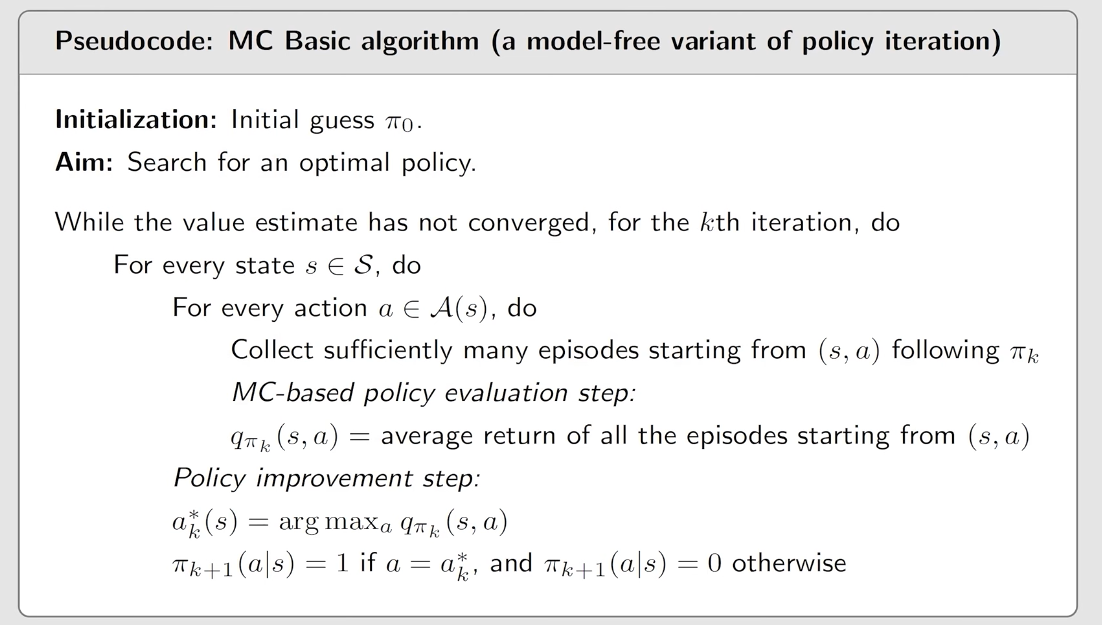

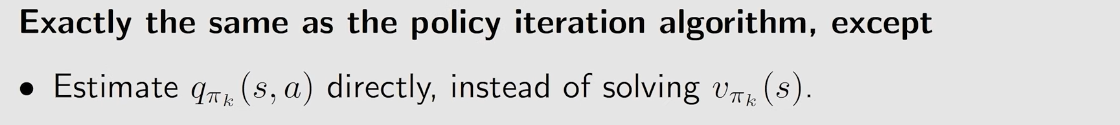

# Keypoints:
- MC basic is a variant of policy iteration algorithm
- The model-free algorithm are build up based on model-based one
- MC basic is useful to reveal the core idea of Monte-Carlo-based model-free RL, but not practical due to low efficiency.
- Why does MC basic estimates action values instead of state values?
  - because state values cannot be used to improve policies directly. When models are not available we should directly estimate action values.
- Since policy iteration is convergent, the convergence of MC basic is also guaranteed, given sufficient episodes. 

## Data structure of Policy and Q value (action-state value)
For this implementation, we will represent the policy as a 1D array, where the index corresponds to the 1D state index and the value represents the action index.

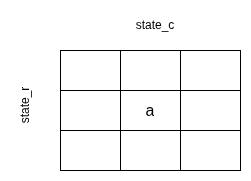


On the other hand, we will represent the Q-value table as a 2D matrix, where each row corresponds to the 1D state index, each column corresponds to the action index, and each value represents the Q-value for that state–action pair.

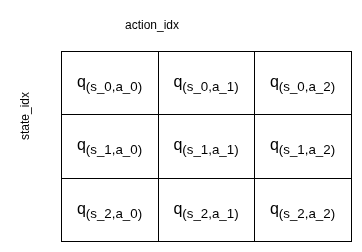


In [7]:
def run_episode(env, policy, state, action_idx, gamma=0.99, max_steps=1000, episode_num=0, verbose=0):
    """
    verbose : 
      - 0 : None 
      - 1 : CLI
      - 2 : GUI  
    """
    
    total_reward = 0
    for step in range(max_steps):        
        out = env.step(state, action_idx)
        next_state = out["new_state"]
        reward = out["reward"]
        is_terminated = out["is_terminated"]
        
        total_reward += gamma**step * reward

        prev_state = state
        state = next_state
        action_idx = policy[state.idx]

        
        if verbose == 1:
            print(f"step {step}: current_state: {prev_state.coord} -> Action: {env.action_idx_to_name[action_idx]}{action_idx} -> Reward: {reward} -> Next state: {next_state.coord}")
        elif verbose == 2:
            env.render(policy, current_state, episode_num, step, total_reward)
            
        if is_terminated:
            break  
            
    return total_reward

In [8]:
frozen_lake.grid

[['F', 'F', 'F'], ['F', 'H', 'F'], ['F', 'F', 'G']]

In [9]:
policy = np.zeros(frozen_lake.n_states)
print("Initial policy: ", policy)

Initial policy:  [0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [10]:
current_state = State((0, 0), frozen_lake.n_cols)

run_episode(env=frozen_lake,
            policy=policy,
            state=current_state,
            action_idx=2,
            episode_num=0,
            verbose=2)

,0,1,2
0,🤖,❄️ ←,❄️ ←
1,❄️ ←,🕳️,❄️ ←
2,❄️ ←,❄️ ←,🏁


0.0

In [11]:
def policy_evaluation(env, policy, Q, gamma=0.99, num_episode=100, max_steps=1000):
    for s in range(env.n_states):
        for a in env.all_action_idx:
            current_state = State(s, env.n_cols)
            total_G = 0
            for e in range(num_episode):
                total_G += run_episode(env,
                                       policy,
                                       current_state,
                                       a,
                                       gamma=gamma,
                                       episode_num=e,
                                       max_steps=max_steps,
                                       verbose=0)

            avg_G = total_G / num_episode
            Q[current_state.idx][a] = avg_G
    return Q

In [12]:
def policy_improvement(env, Q):
    new_policy = np.zeros(env.n_states, dtype=np.int8)
    for s in range(env.n_states):
        state = State(s, env.n_cols)
        r, c  = state.coord
        
        if env.grid[r][c] in env.terminal_states:
            continue
            
        action_values = []
        for action in env.all_action_idx:                
            q = Q[state.idx][action]
            action_values.append(q)
            
        # pick a greedy action with a highest action value
        new_policy[state.idx] = np.argmax(action_values).item()
    return new_policy

In [13]:
def mc_basic_run(env, num_episode=1000, max_steps=1000, gamma=0.99):
    policy_history = []
    Q_history = []
    n_rows = env.n_rows
    n_cols = env.n_cols
    policy = np.zeros(env.n_states, dtype=np.int8)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float32)
    while True:
        Q = policy_evaluation(env,
                              policy,
                              Q,
                              gamma,
                              num_episode,
                              max_steps)
        new_policy = policy_improvement(env, Q)
        
        if np.array_equal(policy, new_policy):
            break
    
        policy = new_policy
        policy_history.append(policy)
        Q_history.append(Q)
        
    return policy, Q, policy_history, Q_history

In [14]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points = reward_points,
                                    slippery=True)

In [15]:
policy, Q, policy_history, Q_history = mc_basic_run(frozen_lake, num_episode=100, max_steps=100)

In [16]:
policy

array([2, 2, 1, 3, 0, 1, 2, 2, 0], dtype=int8)

In [17]:
Q

array([[6.798717 , 6.7767706, 7.7155657, 6.871451 ],
       [6.7369437, 1.9214625, 7.4429193, 5.735699 ],
       [7.6921363, 9.141425 , 7.6711016, 8.152058 ],
       [5.775095 , 6.173804 , 2.456315 , 6.2363257],
       [0.       , 0.       , 0.       , 0.       ],
       [3.0732384, 8.861387 , 7.784932 , 7.6891127],
       [8.499386 , 8.353983 , 8.897861 , 7.1274567],
       [7.973995 , 7.6064773, 9.067386 , 3.0661795],
       [0.       , 0.       , 0.       , 0.       ]], dtype=float32)

let's convert policy into 2D

In [18]:
def convert_1d_to_2d_policy(policy_1d, n_rows, n_cols):
    policy_2d = np.zeros((n_rows, n_cols),dtype=np.int16)

    for idx, value in enumerate(policy_1d):
        r, c = State(idx, n_cols).coord
        policy_2d[r][c] = value
    return policy_2d

In [19]:
policy_2d = convert_1d_to_2d_policy(policy, frozen_lake.n_rows, frozen_lake.n_cols)
policy_2d

array([[2, 2, 1],
       [3, 0, 1],
       [2, 2, 0]], dtype=int16)

# Render policy

In [20]:
import pandas as pd
from IPython.display import display

In [21]:
render_policy_and_value(frozen_lake, policy, Q)

Policy:


,0,1,2
0,→,→,↓
1,↑,🕳️,↓
2,→,→,🏁


State-Value Function:


,0,1,2,3
0,6.80,6.78,7.72,6.87
1,6.74,1.92,7.44,5.74
2,7.69,9.14,7.67,8.15
3,5.78,6.17,2.46,6.24
4,0.00,0.00,0.00,0.00
5,3.07,8.86,7.78,7.69
6,8.50,8.35,8.90,7.13
7,7.97,7.61,9.07,3.07
8,0.00,0.00,0.00,0.00


# Animate policy and state value history

In [22]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [23]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())

# Let Play with different grid setup

In [26]:
grid = generate_grid_randomly(4, 4, n_holes=3)
grid

[['F', 'F', 'H', 'F'],
 ['F', 'H', 'F', 'S'],
 ['F', 'H', 'F', 'G'],
 ['F', 'F', 'F', 'F']]

In [27]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)

policy, Q, policy_history, V_history = mc_basic_run(frozen_lake, num_episode=100, max_steps=100)

In [28]:
len(policy_history)

130

In [29]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())